In [24]:
import numpy as np
import pandas as pd
from sklearn.manifold import TSNE
import matplotlib.pyplot as plt
data = pd.read_csv("posture_data_2.csv")



In [25]:
X_embedded = TSNE(n_components=2, learning_rate='auto',
                  init='random', perplexity=3).fit_transform(data)
X_embedded.shape

(2000, 2)

TSNE Visualisation

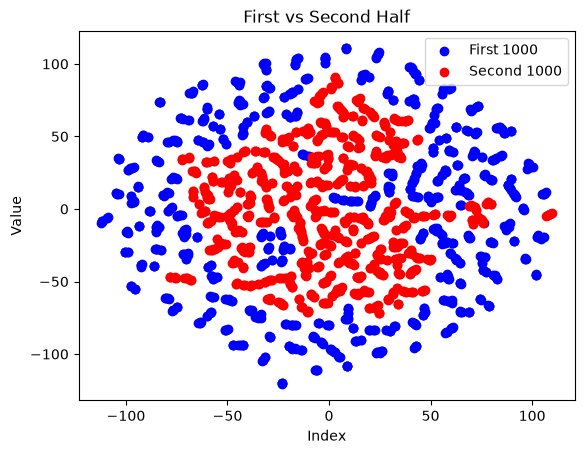

In [26]:
# Split into two parts
df1 = X_embedded[:1000]     # first 1000 rows
df2 = X_embedded[1000:2000] # next 1000 rows

# Plot
plt.scatter(df1[:, 0], df1[:, 1], color='blue', label='First 1000')
plt.scatter(df2[:, 0], df2[:, 1], color='red', label='Second 1000')

plt.legend()
plt.xlabel("Index")
plt.ylabel("Value")
plt.title("First vs Second Half")

plt.show()


Looking at feature differences between high and low positions of the computer 

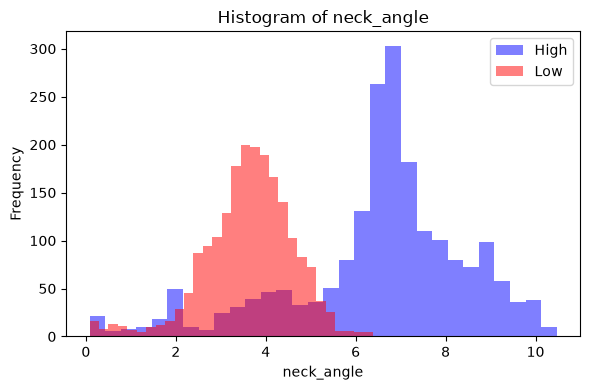

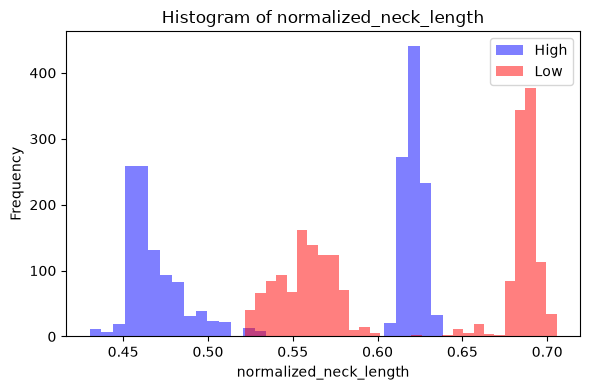

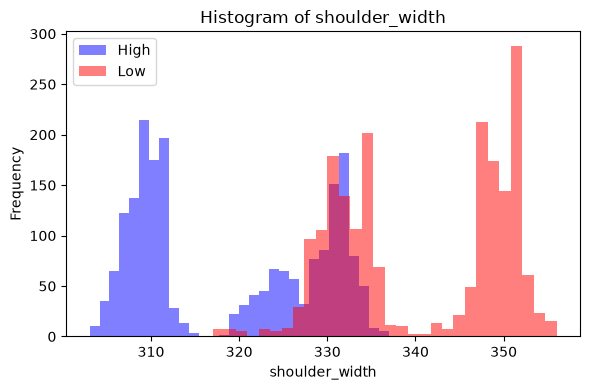

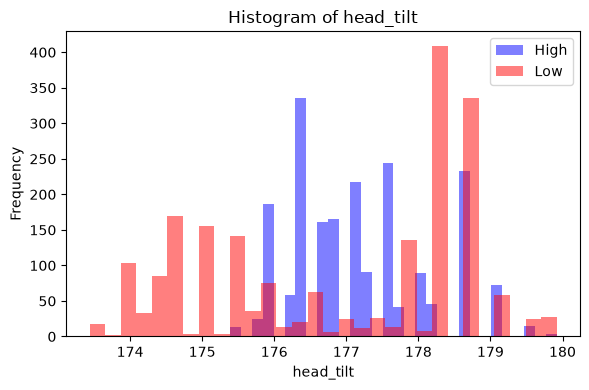

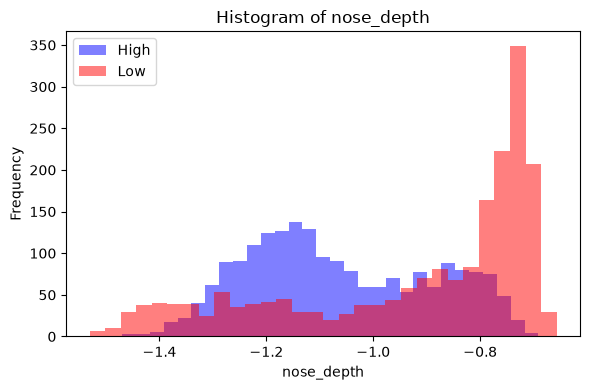

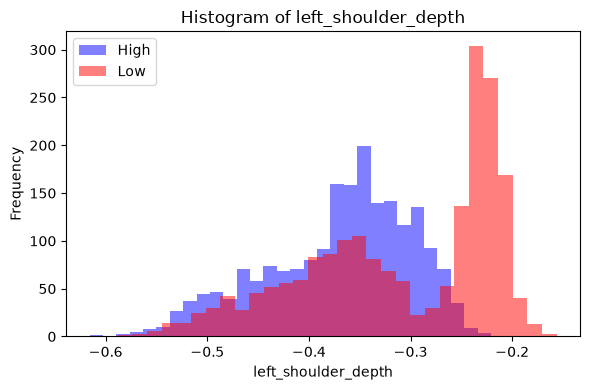

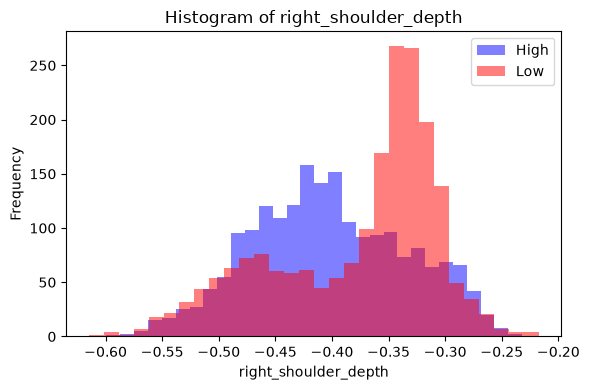

In [ ]:
# Load data
high_posture = pd.read_csv("posture_data_1.csv")
low_posture = pd.read_csv("posture_data_2.csv")

# Loop through each column
for col in high_posture.columns:
    plt.figure(figsize=(6, 4))
    
    # Plot both histograms on the same plot
    plt.hist(high_posture[col], bins=30, alpha=0.5, label='High', color='blue')
    plt.hist(low_posture[col], bins=30, alpha=0.5, label='Low', color='red')
    
    # Labels and title
    plt.title(f'Histogram of {col}')
    plt.xlabel(col)
    plt.ylabel('Frequency')
    
    # Legend
    plt.legend()
    
    plt.tight_layout()
    plt.show()

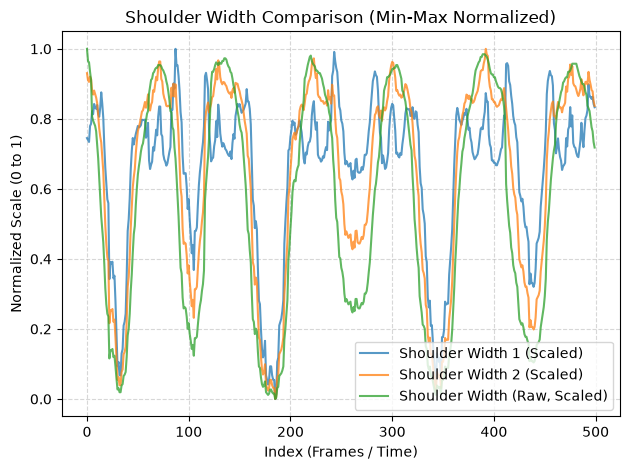

--- SHOULDER WIDTH ANALYSIS ---
Correlation SW1 vs SW2: 0.88
Correlation SW1 vs Raw: 0.71
Correlation SW2 vs Raw: 0.96

--- SHOULDER WIDTH 1 EXTREMES ---
Top 10 HIGHEST indices: [87, 243, 244, 413, 412, 89, 88, 414, 245, 242]
Top 10 LOWEST indices:  [185, 186, 178, 343, 348, 179, 184, 177, 183, 33]

--- SHOULDER WIDTH 2 EXTREMES ---
Top 10 HIGHEST indices: [392, 393, 394, 223, 391, 129, 222, 71, 72, 300]
Top 10 LOWEST indices:  [185, 186, 178, 343, 348, 179, 184, 177, 183, 33]

--- RAW SHOULDER WIDTH EXTREMES ---
Top 10 HIGHEST indices: [0, 389, 390, 391, 220, 392, 219, 387, 388, 393]
Top 10 LOWEST indices:  [185, 186, 178, 343, 177, 179, 183, 184, 348, 32]


In [2]:
import pandas as pd
import matplotlib.pyplot as plt

# Load your data
data = pd.read_csv("posture_data_test.csv")


# -------------------------------------------------------------
# Min-Max Normalization (Scales values between 0 and 1)
# -------------------------------------------------------------
data["shoulderwidth_1_scaled"] = (
    (data["normalized_shoulderwidth_1"] - data["normalized_shoulderwidth_1"].min()) /
    (data["normalized_shoulderwidth_1"].max() - data["normalized_shoulderwidth_1"].min() + 1e-6)
)

data["shoulderwidth_2_scaled"] = (
    (data["normalized_shoulderwidth_2"] - data["normalized_shoulderwidth_2"].min()) /
    (data["normalized_shoulderwidth_2"].max() - data["normalized_shoulderwidth_2"].min() + 1e-6)
)

data["shoulderwidth_raw_scaled"] = (
    (data["shoulderwidth_nontransformed"] - data["shoulderwidth_nontransformed"].min()) /
    (data["shoulderwidth_nontransformed"].max() - data["shoulderwidth_nontransformed"].min() + 1e-6)
)

# -------------------------------------------------------------
# Find Top 10 Highest and Lowest Indices
# -------------------------------------------------------------
top_10_high_sw1 = data["normalized_shoulderwidth_1"].nlargest(10).index.tolist()
top_10_low_sw1 = data["normalized_shoulderwidth_1"].nsmallest(10).index.tolist()

top_10_high_sw2 = data["normalized_shoulderwidth_2"].nlargest(10).index.tolist()
top_10_low_sw2 = data["normalized_shoulderwidth_2"].nsmallest(10).index.tolist()

top_10_high_raw = data["shoulderwidth_nontransformed"].nlargest(10).index.tolist()
top_10_low_raw = data["shoulderwidth_nontransformed"].nsmallest(10).index.tolist()

# -------------------------------------------------------------
# Plotting the Scaled Data
# -------------------------------------------------------------
plt.plot(data["shoulderwidth_1_scaled"], label="Shoulder Width 1 (Scaled)", alpha=0.75)
plt.plot(data["shoulderwidth_2_scaled"], label="Shoulder Width 2 (Scaled)", alpha=0.75)
plt.plot(data["shoulderwidth_raw_scaled"], label="Shoulder Width (Raw, Scaled)", alpha=0.75)

plt.xlabel("Index (Frames / Time)")
plt.ylabel("Normalized Scale (0 to 1)")
plt.title("Shoulder Width Comparison (Min-Max Normalized)")

plt.grid(True, linestyle="--", alpha=0.5)
plt.legend()
plt.tight_layout()
plt.show()

# -------------------------------------------------------------
# Console Outputs
# -------------------------------------------------------------
print("--- SHOULDER WIDTH ANALYSIS ---")

corr_1_2 = data["normalized_shoulderwidth_1"].corr(data["normalized_shoulderwidth_2"])
corr_1_raw = data["normalized_shoulderwidth_1"].corr(data["shoulderwidth_nontransformed"])
corr_2_raw = data["normalized_shoulderwidth_2"].corr(data["shoulderwidth_nontransformed"])

print(f"Correlation SW1 vs SW2: {corr_1_2:.2f}")
print(f"Correlation SW1 vs Raw: {corr_1_raw:.2f}")
print(f"Correlation SW2 vs Raw: {corr_2_raw:.2f}\n")

print("--- SHOULDER WIDTH 1 EXTREMES ---")
print(f"Top 10 HIGHEST indices: {top_10_high_sw1}")
print(f"Top 10 LOWEST indices:  {top_10_low_sw1}\n")

print("--- SHOULDER WIDTH 2 EXTREMES ---")
print(f"Top 10 HIGHEST indices: {top_10_high_sw2}")
print(f"Top 10 LOWEST indices:  {top_10_low_sw2}\n")

print("--- RAW SHOULDER WIDTH EXTREMES ---")
print(f"Top 10 HIGHEST indices: {top_10_high_raw}")
print(f"Top 10 LOWEST indices:  {top_10_low_raw}")

In [4]:
mean1 = data["normalized_shoulderwidth_1"].mean()
mean2 = data["normalized_shoulderwidth_2"].mean()
max_raw = data["shoulderwidth_nontransformed"].max()
print(f"\nMean Normalized Shoulder Width 1: {mean1:.4f}")
print(f"Mean Normalized Shoulder Width 2: {mean2:.4f}") 
print(f"Max Raw Shoulder Width: {max_raw:.4f}")


Mean Normalized Shoulder Width 1: 228.3341
Mean Normalized Shoulder Width 2: 176.1923
Max Raw Shoulder Width: 256.0000


In [10]:

import torch
from PIL import Image
import numpy as np
import matplotlib.pyplot as plt
import depth_pro

# Device setup
device = "cuda" if torch.cuda.is_available() else "cpu"
print("Using device:", device)

# Load model
model, transform = depth_pro.create_model_and_transforms()
model.eval()

Using device: cuda


: 

In [9]:
next(model.parameters()).device

device(type='cpu')

In [3]:

# Load image
image, _, f_px = depth_pro.load_rgb(r"C:\Users\ChuTs\OneDrive - Government of Ontario\Desktop\Current Projects\The-Posture-Project-\ml-depth-pro\data\example.jpg")

# Transform + send to GPU
image = transform(image)

# Inference
with torch.no_grad():
    prediction = model.infer(image, f_px=f_px)

depth = prediction["depth"]
depth

KeyboardInterrupt: 

In [2]:

import torch
print(torch.cuda.device_count())

1
